In [24]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm

  Preparing metadata (setup.py) ... done
  Created wheel for tdqm: filename=tdqm-0.0.1-py3-none-any.whl size=1320 sha256=fd67975839eec10dc06dcf8346ebef766322da14b836b953b0ea054f322da265
  Stored in directory: /root/.cache/pip/wheels/c8/c7/30/e5935be2cfa6883be72462333edc414d8928f3c78eaabec38a
Successfully built tdqm


**1. Определить формат ссылки для пагинации**

Базовая часть ссылки для пагинации - https://lifehacker.ru/topics/technology/

In [32]:
base_url = 'https://lifehacker.ru' # базовая часть ссылки, позже в цикле будем добавлять к ней пагинацию

Ссылки для перехода на следующую страницу

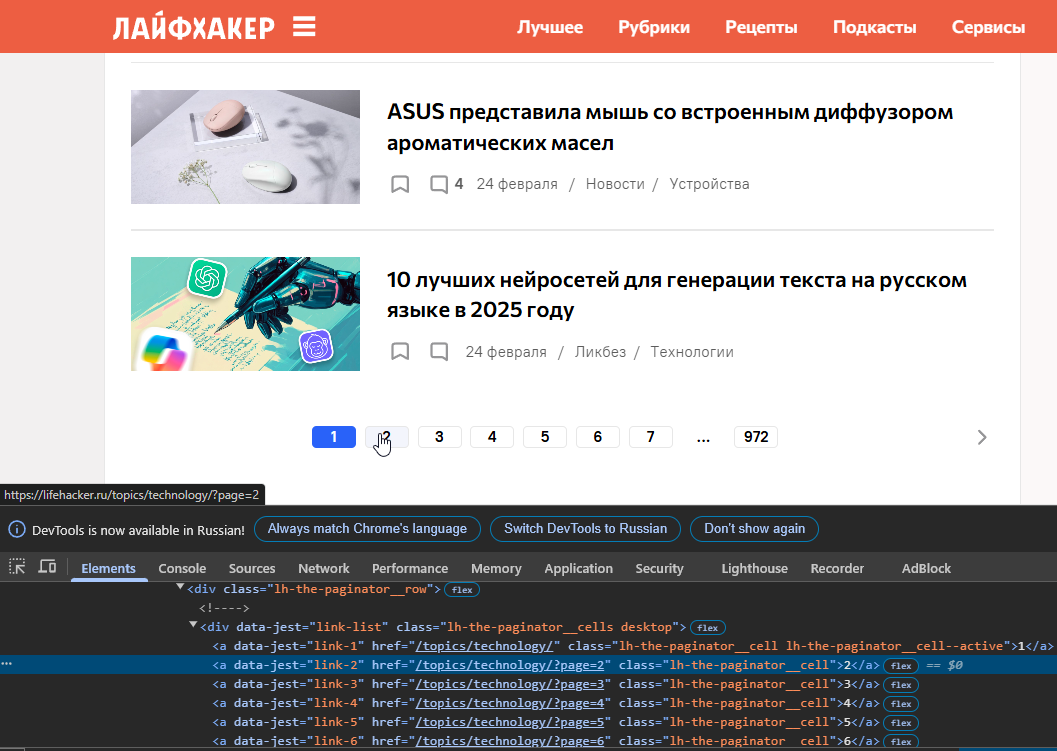

**2. В разметке страницы найти уникальные классы/идентификаторы блока с названием и содержанием материала**

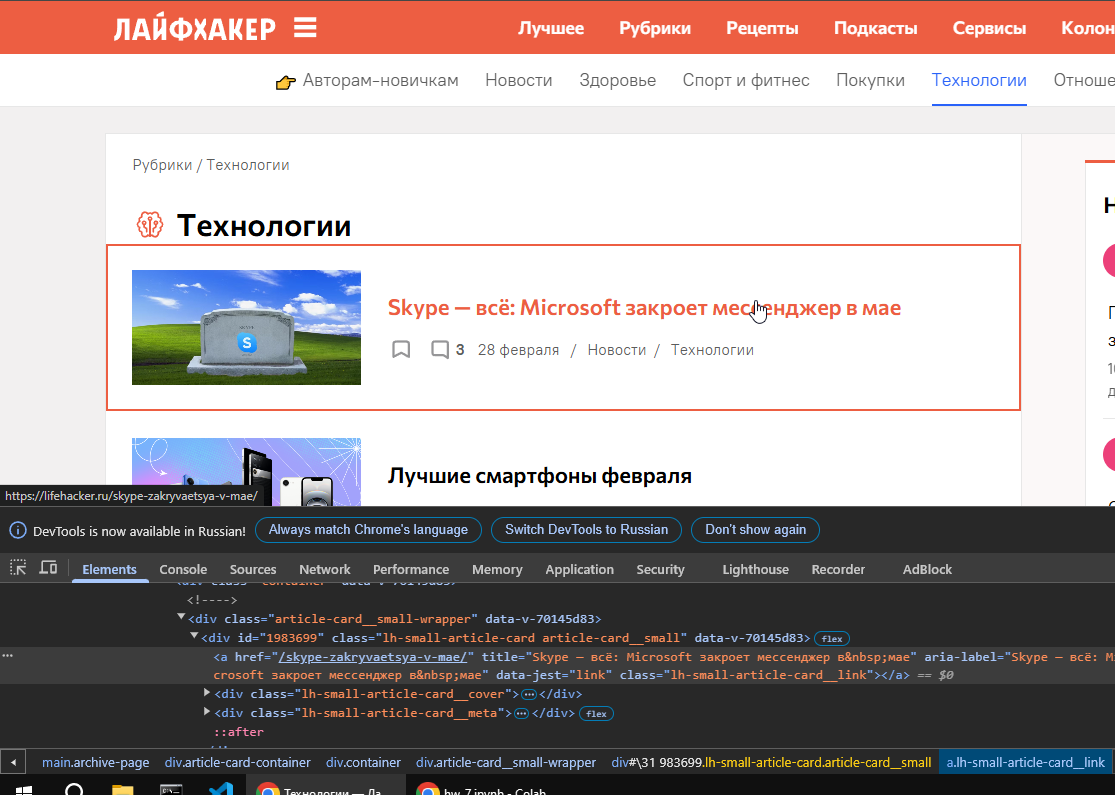

У ссылок на кнопках перехода к статье есть специальный класс _lh-small-article-card__link_

**3. Получить содержимое десяти страниц списка материалов, выделить из него ссылки на каждый материал**

Сначала попробуем получить ссылки на материалы с первой страницы

In [33]:
response = requests.get(f'{base_url}/topics/technology/?page=1') # получаем контент первой страиниц
soup = BeautifulSoup(response.text, 'lxml') # инициализируем объект bs4 и задаем парсер lxml

In [34]:
raw_items = soup.find_all('a', class_='lh-small-article-card__link') # ищем все a-элементы с классом lh-small-article-
raw_items[:5]

[<a aria-label="Skype — всё: Microsoft закроет мессенджер в&amp;nbsp;мае" class="lh-small-article-card__link" data-jest="link" href="/skype-zakryvaetsya-v-mae/" title="Skype — всё: Microsoft закроет мессенджер в&amp;nbsp;мае"></a>,
 <a aria-label="Лучшие смартфоны февраля" class="lh-small-article-card__link" data-jest="link" href="/smartfony-fevralya-2025/" title="Лучшие смартфоны февраля"></a>,
 <a aria-label="Infinix представила концепт первой тройной вертикальной раскладушки" class="lh-small-article-card__link" data-jest="link" href="/anons-infinix-zero-series-mini-tri-fold/" title="Infinix представила концепт первой тройной вертикальной раскладушки"></a>,
 <a aria-label="Обзор Honor Magicbook X14 2025 — компактного ноутбука с отличной автономностью и удобной клавиатурой&amp;nbsp;" class="lh-small-article-card__link" data-jest="link" href="/obzor-honor-magicbook-x14-2025/" title="Обзор Honor Magicbook X14 2025 — компактного ноутбука с отличной автономностью и удобной клавиатурой&amp

In [35]:
links = [item.get('href') for item in raw_items] # получаем у ссылок только href-атрибут
links

['/skype-zakryvaetsya-v-mae/',
 '/smartfony-fevralya-2025/',
 '/anons-infinix-zero-series-mini-tri-fold/',
 '/obzor-honor-magicbook-x14-2025/',
 '/pasxalka-s-naruto/',
 '/anons-gpt-4-5/',
 '/chto-takoe-zaplanirovannoe-ustarevanie-smartfona/',
 '/anons-xiaomi-buds-5-pro/',
 '/nadoevshie-trendy-v-smartfonax/',
 '/anons-xiaomi-15-ultra/',
 '/volte-texnologiya-peredachi-golosa/',
 '/obzor-honor-pad-v9/',
 '/microsoft-testiruet-besplatnyi-office/',
 '/aksessuary-smartfon/',
 '/servis-dlya-vyxoda-na-pensiyu-na-gosuslugax/',
 '/chexol-clicks-dlya-android/',
 '/adobe-vypustila-photoshop-dlya-iphone/',
 '/kak-vybrat-shurupovyort/',
 '/10-luchshix-aerogrilej-dlya-doma-v-2025-godu/',
 '/robot-delaet-salto-vpered/',
 '/anons-kofemashiny-mijia-s1/',
 '/anons-realme-neo7-se/',
 '/obzor-honor-magic-7-pro/',
 '/gmail-qr-kod/',
 '/chat-s-alisoi-na-yandexgpt-5-pro/',
 '/aksessuary-ot-storonnix-proizvoditelei/',
 '/anons-jbl-flip-7/',
 '/microsoft-obnovila-pusk/',
 '/anons-asus-fragrance-mouse/',
 '/nejr

Теперь произведем эту операцию для десяти страниц

In [36]:
parsed_urls = []
for page_num in range(1, 11):
    url = f'{base_url}/topics/technology/?page={page_num}' # подставляем нужный номер страницы для пагинации, дальше парсим каждую страницу
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'lxml')
    raw_items = soup.find_all('a', class_='lh-small-article-card__link')
    parsed_urls += [item.get('href') for item in raw_items]


In [38]:
parsed_urls[:5]

['/skype-zakryvaetsya-v-mae/',
 '/smartfony-fevralya-2025/',
 '/anons-infinix-zero-series-mini-tri-fold/',
 '/obzor-honor-magicbook-x14-2025/',
 '/pasxalka-s-naruto/']

In [39]:
len(parsed_urls)

300

**4. Перебрать все полученные ссылки и получить html-код каждого материала**

In [42]:
articles_html_texts = []
for material_url in tqdm(parsed_urls):
  try:
    articles_html_texts.append(requests.get(base_url + material_url))
  except:
    print(f"Can't connect to {base_url + material_url}")

 40%|████      | 121/300 [03:03<05:01,  1.69s/it]

Can't connect to https://lifehacker.ruhttps://lifehacker.ru/special/nejroseti/


100%|██████████| 300/300 [07:48<00:00,  1.56s/it]


**5. Распарсить полученный текст разметки с помощью BeautifulSoup, вытащив по каждой ссылке заголовок и содержание материала**

Название:

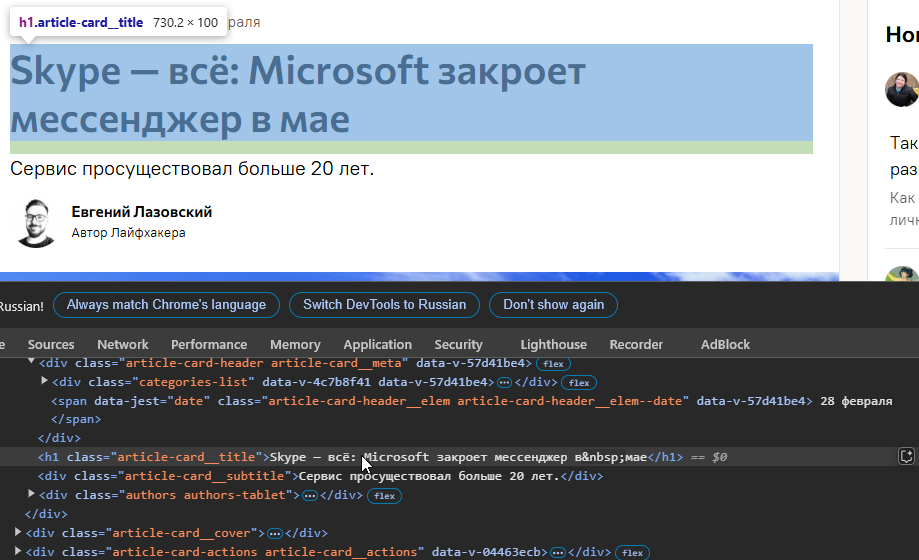

Текст:

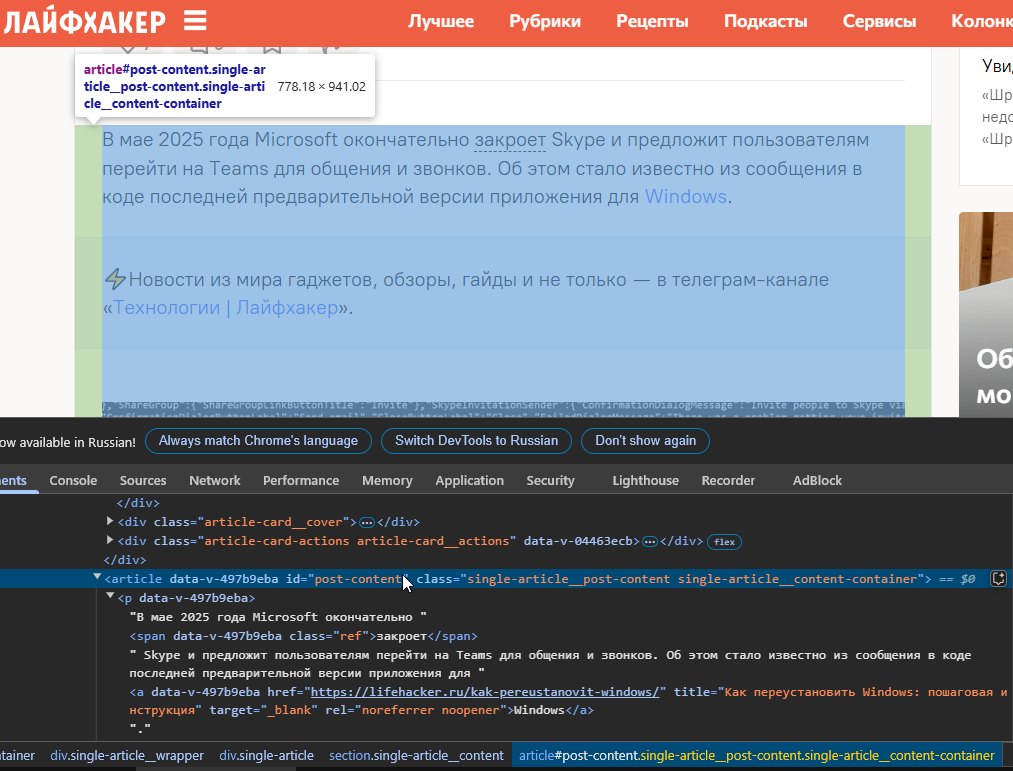

В данном случае классом single-article__post обладает div, a не article, т.е. подразумевается, что в блок article еще неявно включен div (непонятно, почему), поэтому ищем по div.

Распарсим одну страницу

In [100]:
soup = BeautifulSoup(articles_html_texts[0], 'lxml')
post_content = soup.find('div', class_='single-article__post-content')
p_list = post_content.find_all('p')

article = {}
article['title'] = soup.find('h1', class_='article-card__title').text.replace("\xa0", " ") # Получаем текст в первом h1 с классом article-card__title
article['text'] = ""
for p in p_list:
  # p.replace()
  article['text'] += p.get_text().replace("\xa0", " ")

article

{'title': 'Skype — всё: Microsoft закроет мессенджер в мае',
 'text': 'В мае 2025 года Microsoft окончательно закроет Skype и предложит пользователям перейти на Teams для общения и звонков. Об этом стало известно из сообщения в коде последней предварительной версии приложения для Windows.Skype был запущен в 2003 году и стал одним из самых популярных сервисов для видеозвонков и обмена сообщениями. В 2011 году Microsoft приобрела сервис и начала постепенно интегрировать его в различные версии Windows. Однако с появлением Teams в 2017 году компания начала смещать акценты и развивать свою платформу для корпоративного общения.Несмотря на попытки улучшить Skype и интегрировать его в систему, сервис не смог конкурировать с такими продуктами, как FaceTime от Apple или сервисами от Google. В последние годы Microsoft активно продвигает Teams, предлагая пользователям бесплатную версию этого приложения для личных нужд.Теперь же Skype окончательно уходит в прошлое, и компания сосредотачивается на T

Распарсим все страницы:

In [101]:
result = []
for article_html_text in tqdm(articles_html_texts):
    soup = BeautifulSoup(article_html_text, 'lxml')

    article_content = soup.find('div', class_='single-article__post-content')
    p_list = article_content.find_all('p')

    article = {}
    article['title'] = soup.find('h1', class_='article-card__title').text.replace("\xa0", " ") # Получаем текст в первом h1 с классом article-card__title
    article['text'] = ""
    for p in p_list:
      # p.replace()
      article['text'] += p.get_text().replace("\xa0", " ")

    result.append(article)

100%|██████████| 299/299 [00:34<00:00,  8.65it/s]


**6. Создать датайфрейм с полученными данными**

In [102]:
pd.set_option('display.max_colwidth', 400)

data = pd.DataFrame(result)
data.head()

,title,text
0,Skype — всё: Microsoft закроет мессенджер в мае,В мае 2025 года Microsoft окончательно закроет Skype и предложит пользователям перейти на Teams для общения и звонков. Об этом стало известно из сообщения в коде последней предварительной версии приложения для Windows.Skype был запущен в 2003 году и стал одним из самых популярных сервисов для видеозвонков и обмена сообщениями. В 2011 году Microsoft приобрела сервис и начала постепенно интегрир...
1,Лучшие смартфоны февраля,"Новая базовая модель для тех, кто хочет современный айфон, но не готов переплачивать. Apple установила в iPhone 16E знакомый 60-герцовый экран с чёлкой, который выполнен по технологии OLED и поддерживает HDR. Дисплей прикрыт прочным стеклом Ceramic Shield, а корпус защищён от воды и пыли по стандарту IP68. Несмотря на стоимость, устройство поддерживает Apple Intelligence, хотя функция пока нед..."
2,Infinix представила концепт первой тройной вертикальной раскладушки,"Infinix анонсировала концептуальный смартфон Zero Series Mini Tri-Fold, который отличается уникальной конструкцией с двумя шарнирами. В отличие от существующих решений с тройным складыванием в горизонтальном формате, эта модель превращается не в планшет, а в компактный смартфон.Главной особенностью концепта стало Z‑образное складывание — это позволяет адаптировать устройство под разные задачи...."
3,Обзор Honor Magicbook X14 2025 — компактного ноутбука с отличной автономностью и удобной клавиатурой,"В Россию приехал обновлённый MagicBook X14 — среднебюджетный ноутбук, нацеленный на продуктивность. Это не игровая модель, а рабочая машинка, от которой требуется надёжность, достаточная производительность для ежедневных задач и хорошая автономность. Я провела с этим ноутбуком неделю, чтобы выяснить, всё ли на месте.Ноутбук поставляется в транспортировочной коробке из плотного картона, внутри ..."
4,В поиске Google появилась пасхалка с теневыми клонами Наруто,"В Google появилась новая пасхалка, посвящённая «Наруто». Если ввести в поиске название аниме, внизу экрана появится оранжевая кнопка. Если на неё нажать, по экрану пробежит 8‑битный Наруто, а за ним — целая армия его теневых клонов, из-за чего картинка начнёт слегка трястись.Этот эффект отсылает к технике теневого клонирования — одному из самых узнаваемых приёмов во франшизе. Хотя он не являет..."
